In [31]:
# Libraries Imports
import kagglehub # for downloading the dataset from kaggle
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.style.use('fivethirtyeight')

In [2]:
# Downloading the dataset
path = kagglehub.dataset_download("vaibhavsxn/google-stock-prices-training-and-test-data")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Bharat\.cache\kagglehub\datasets\vaibhavsxn\google-stock-prices-training-and-test-data\versions\1


In [3]:
# Reading the dataset using Pandas
df_train = pd.read_csv(path + "/Google_Stock_Price_Train.csv",parse_dates=["Date"], index_col=["Date"])
df_test = pd.read_csv(path + "/Google_Stock_Price_Test.csv",parse_dates=["Date"], index_col=["Date"])
df_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2012-01-03,325.25,332.83,324.97,663.59,"7,380,500"
2012-01-04,331.27,333.87,329.08,666.45,"5,749,400"
2012-01-05,329.83,330.75,326.89,657.21,"6,590,300"
2012-01-06,328.34,328.77,323.68,648.24,"5,405,900"
2012-01-09,322.04,322.29,309.46,620.76,"11,688,800"


# Data Wrangling

In [4]:
df_train.dtypes # Checking the data types

Open      float64
High      float64
Low       float64
Close      object
Volume     object
dtype: object

In [5]:
df_test.dtypes # Checking the data types

Open      float64
High      float64
Low       float64
Close     float64
Volume     object
dtype: object

In [6]:
df_train.sort_index(ascending=True, inplace=True)
df_test.sort_index(ascending=True, inplace=True)

In [7]:
df_train['Volume'] = pd.to_numeric(df_train['Volume'].str.replace(',', ''))
df_test['Volume'] = pd.to_numeric(df_test['Volume'].str.replace(',', ''))
df_train['Close'] = pd.to_numeric(df_train['Close'].astype(str).str.replace(',', ''))
# Converting the 'Volume' and 'Close' columns to numeric

In [8]:
df_train.dtypes # Rechecking the data types

Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

In [9]:
df_test.dtypes # Rechecking the data types

Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

In [10]:
df_train.isnull().sum() # Checking for null values

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [11]:
df_test.isnull().sum() # Checking for null values 

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

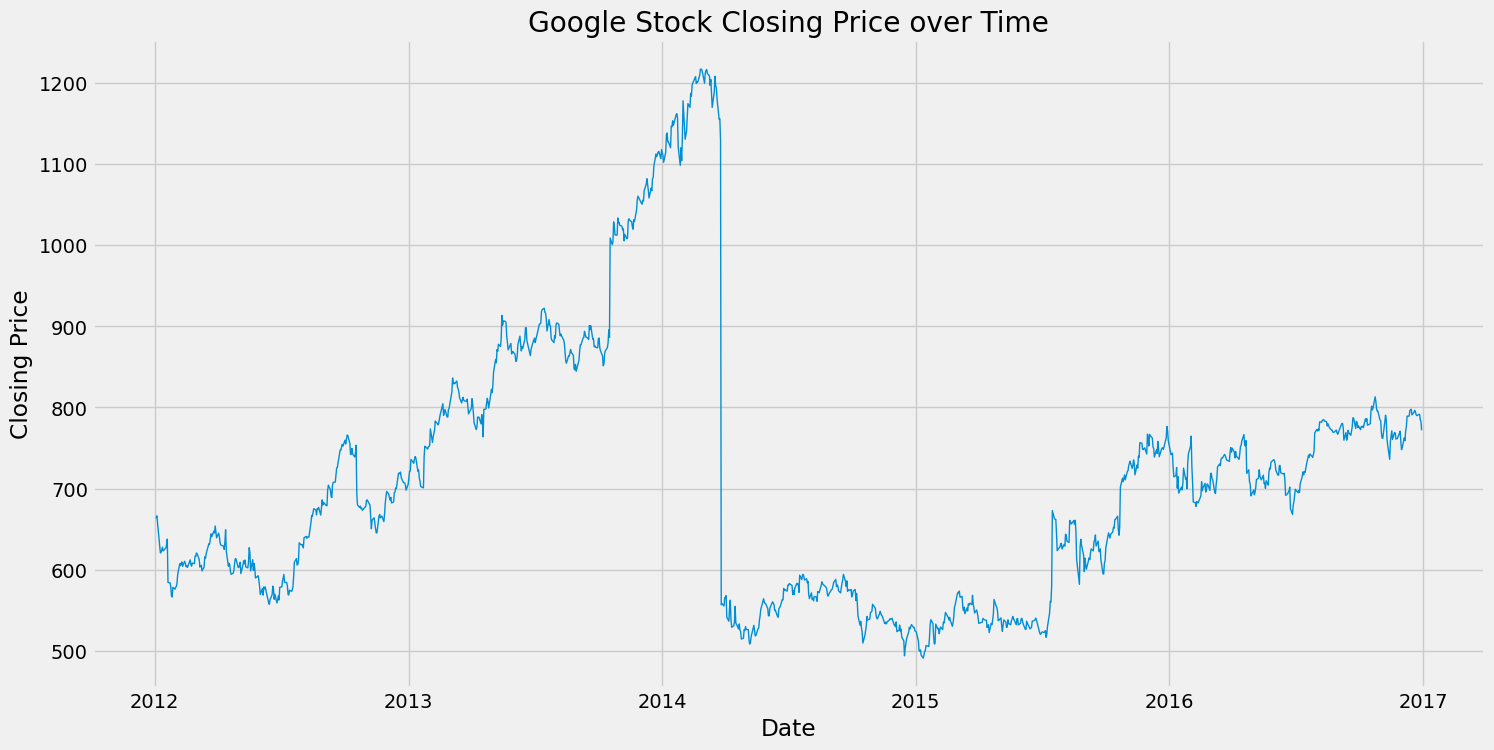

In [12]:
# Plotting the Closing Price
plt.figure(figsize=(16,8))
plt.plot(df_train['Close'], linewidth=1)
plt.title('Google Stock Closing Price over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

# Note : The large sudden drop in the stock price is because 
# In April 2014, Google executed a 2-for-1 stock split
# created a new share class (GOOG and GOOGL).

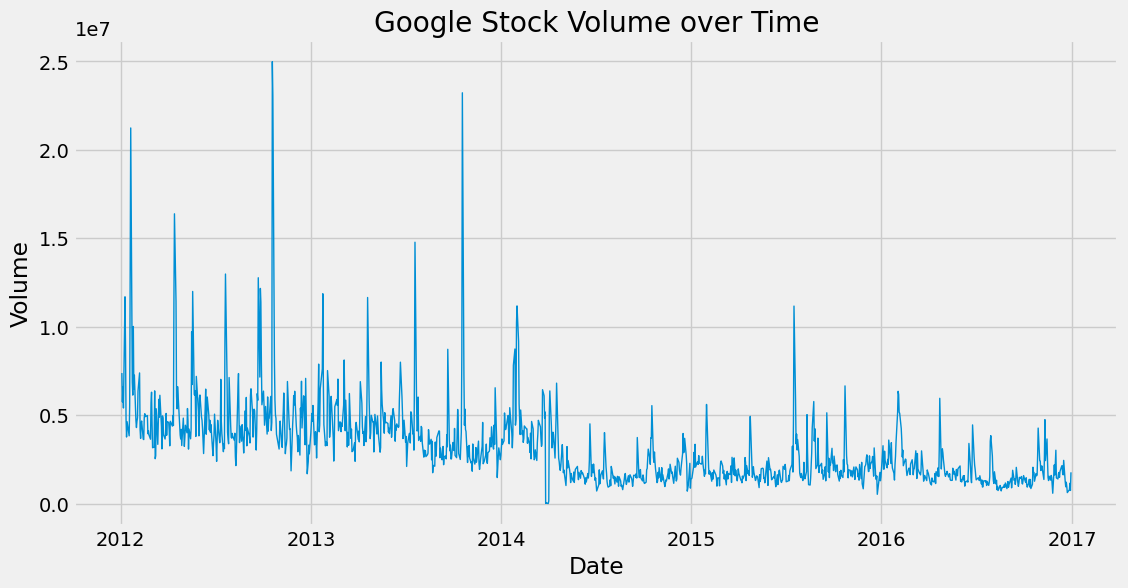

In [13]:
# Plotting the Volume
plt.figure(figsize=(12,6))
plt.plot(df_train['Volume'], linewidth=1)
plt.title('Google Stock Volume over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [14]:
# Feature Enginerring Moving Average
df_train['MA_3'] = df_train['Close'].rolling(3).mean()
df_train['MA_6'] = df_train['Close'].rolling(6).mean()
df_test['MA_3'] = df_test['Close'].rolling(3).mean()
df_test['MA_6'] = df_test['Close'].rolling(6).mean()

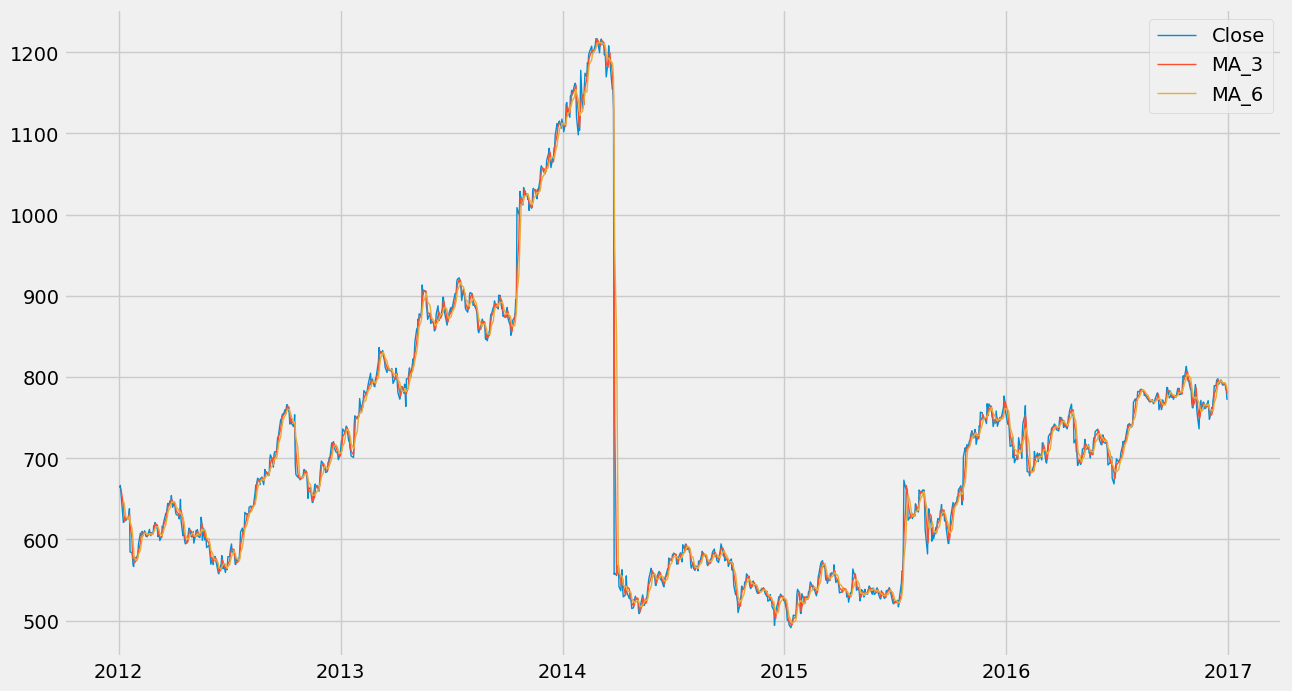

In [15]:
# Plotting the Moving Averages and close price together

plt.figure(figsize=(14,8))

plt.plot(df_train['Close'], linewidth=1)
plt.plot(df_train['MA_3'], linewidth=1)
plt.plot(df_train['MA_6'], linewidth=1)

plt.legend(['Close', 'MA_3', 'MA_6'])

plt.show()

In [16]:

df_train["Return"] = df_train["Close"].pct_change()
df_test["Return"] = df_test["Close"].pct_change()

In [17]:
df_train["HL_Spread"] = df_train["High"] - df_train["Low"]
df_test["HL_Spread"] = df_test["High"] - df_test["Low"]

In [18]:
df_train["Volume_Change"] = df_train["Volume"].pct_change()
df_test["Volume_Change"] = df_test["Volume"].pct_change()
df_train["Volatility"] = df_train["Close"].rolling(5).std()
df_test["Volatility"] = df_test["Close"].rolling(5).std()

In [19]:
print(df_train.isna().sum())
print(df_test.isna().sum())

Open             0
High             0
Low              0
Close            0
Volume           0
MA_3             2
MA_6             5
Return           1
HL_Spread        0
Volume_Change    1
Volatility       4
dtype: int64
Open             0
High             0
Low              0
Close            0
Volume           0
MA_3             2
MA_6             5
Return           1
HL_Spread        0
Volume_Change    1
Volatility       4
dtype: int64


In [20]:
df_train = df_train.dropna()
df_test = df_test.dropna()
df_train.isnull().sum()

Open             0
High             0
Low              0
Close            0
Volume           0
MA_3             0
MA_6             0
Return           0
HL_Spread        0
Volume_Change    0
Volatility       0
dtype: int64

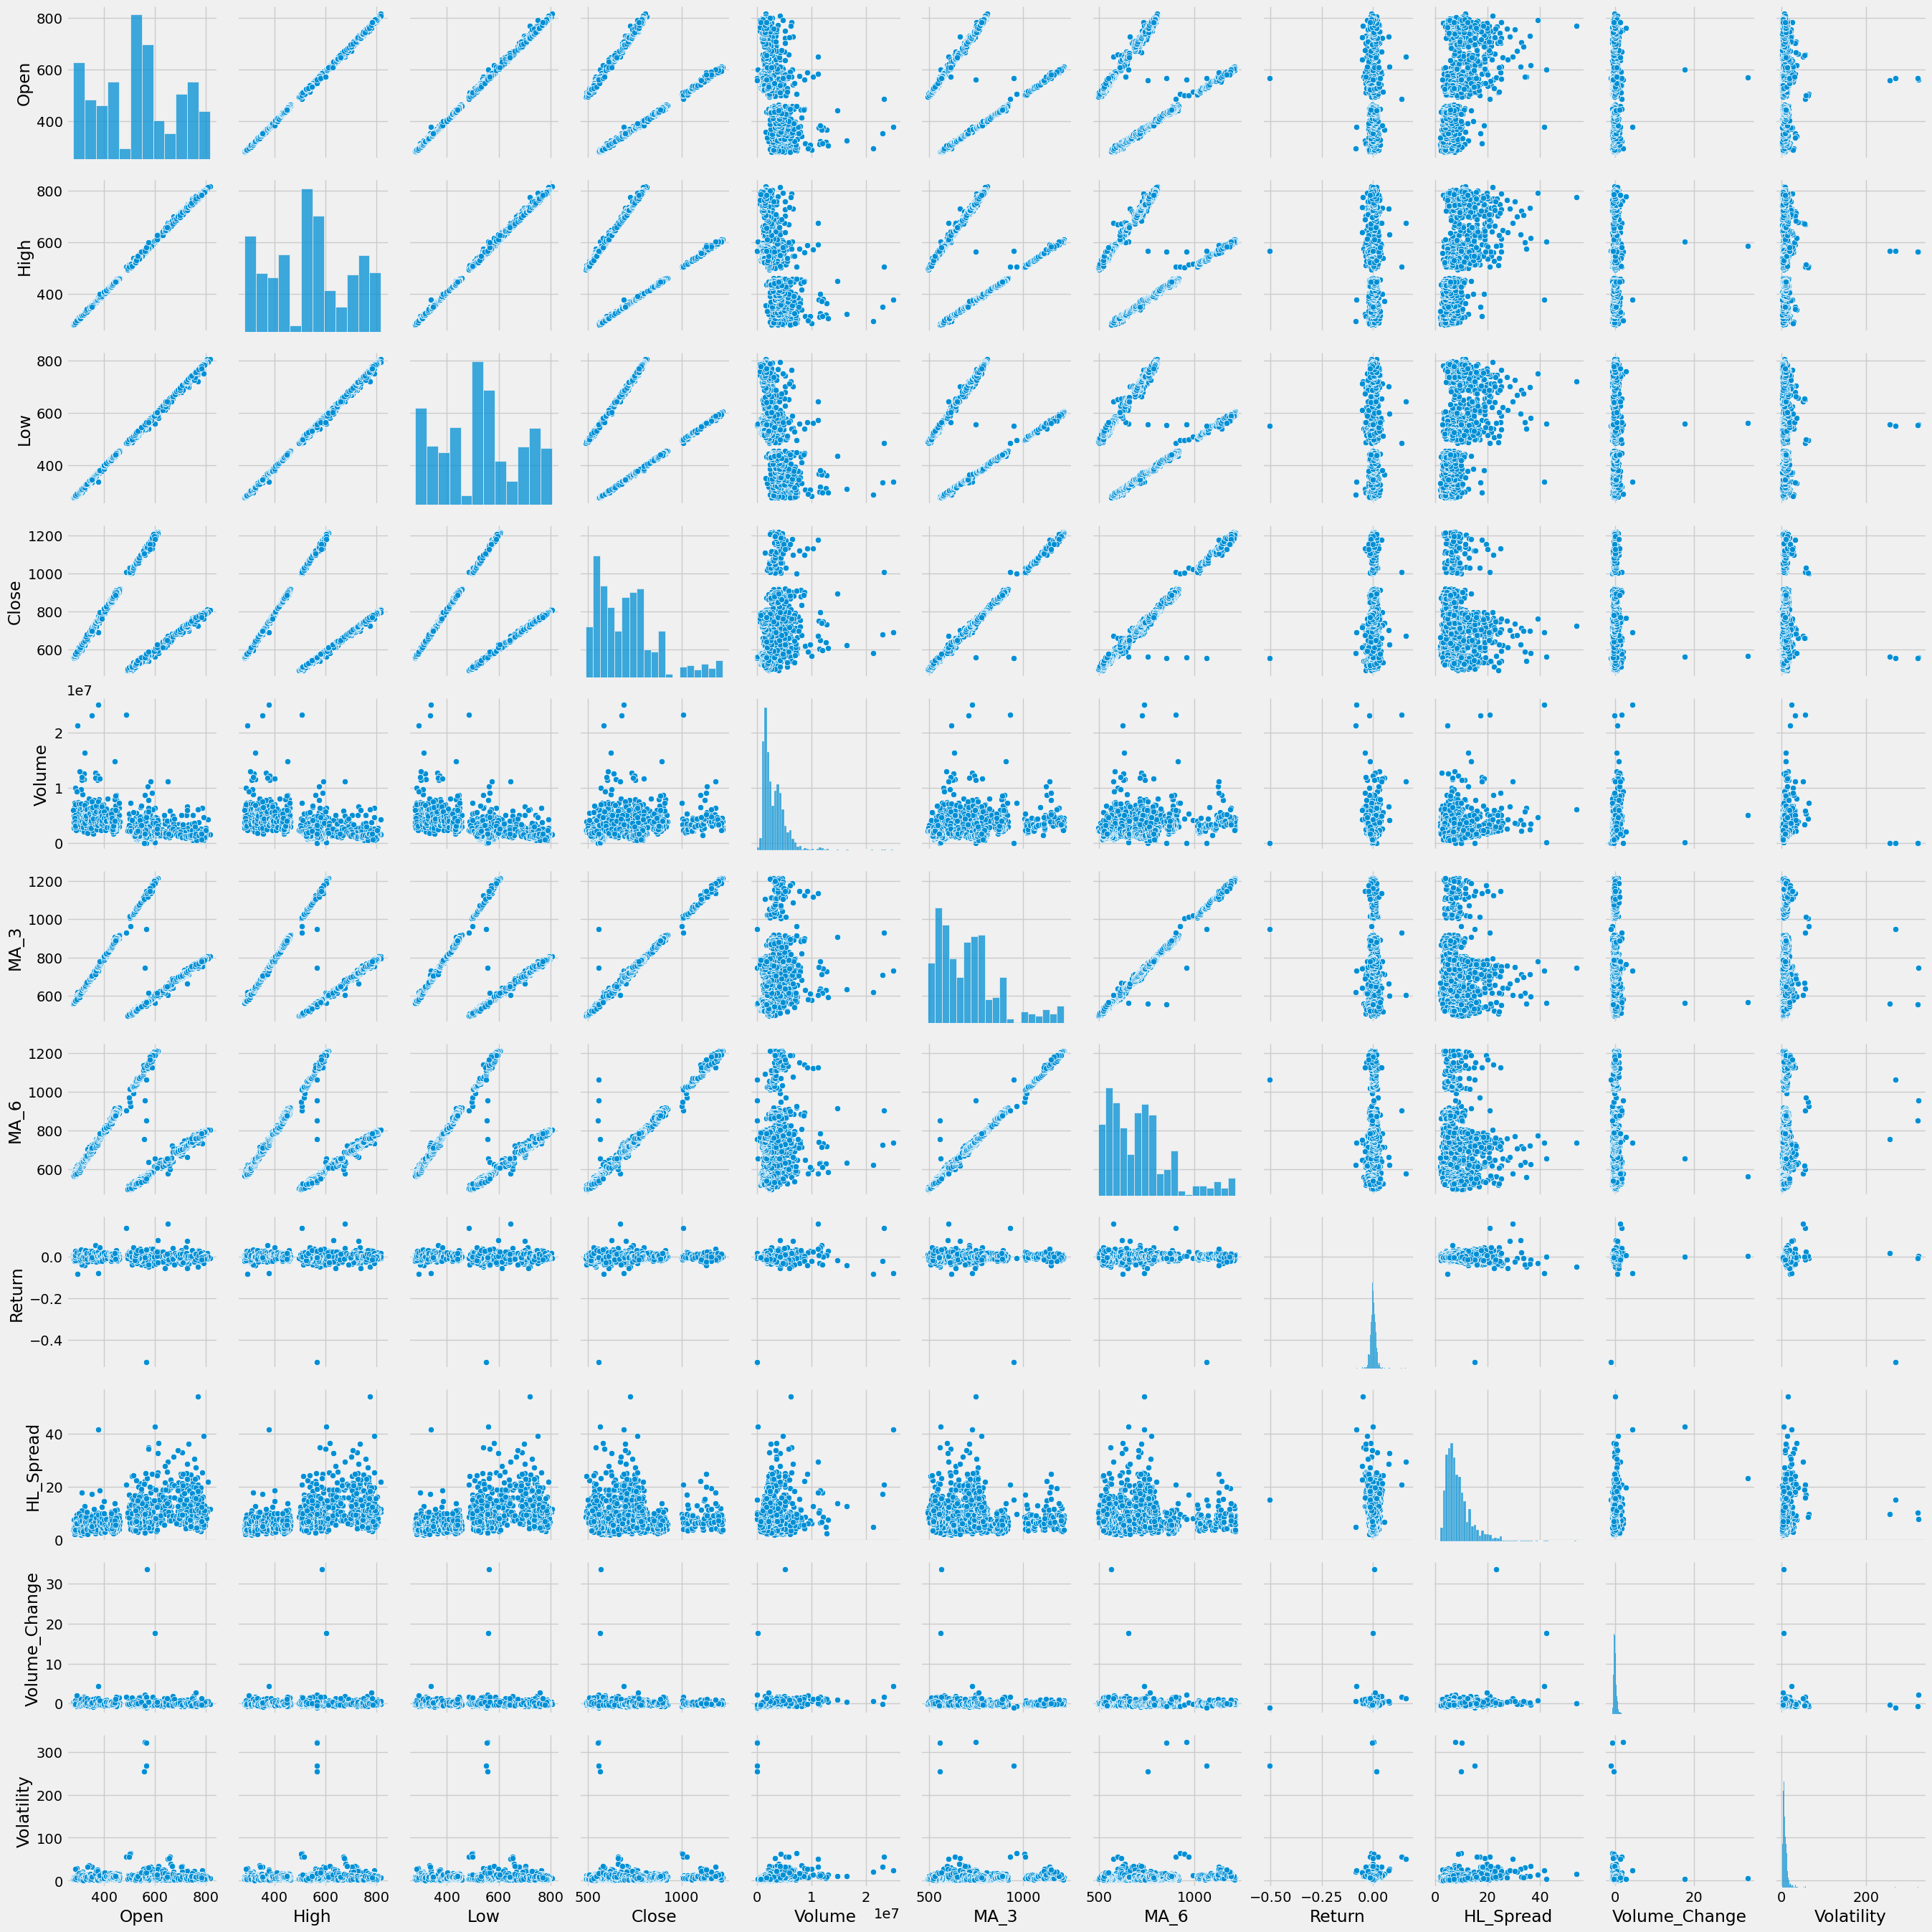

In [21]:
sns.pairplot(df_train)
plt.show()

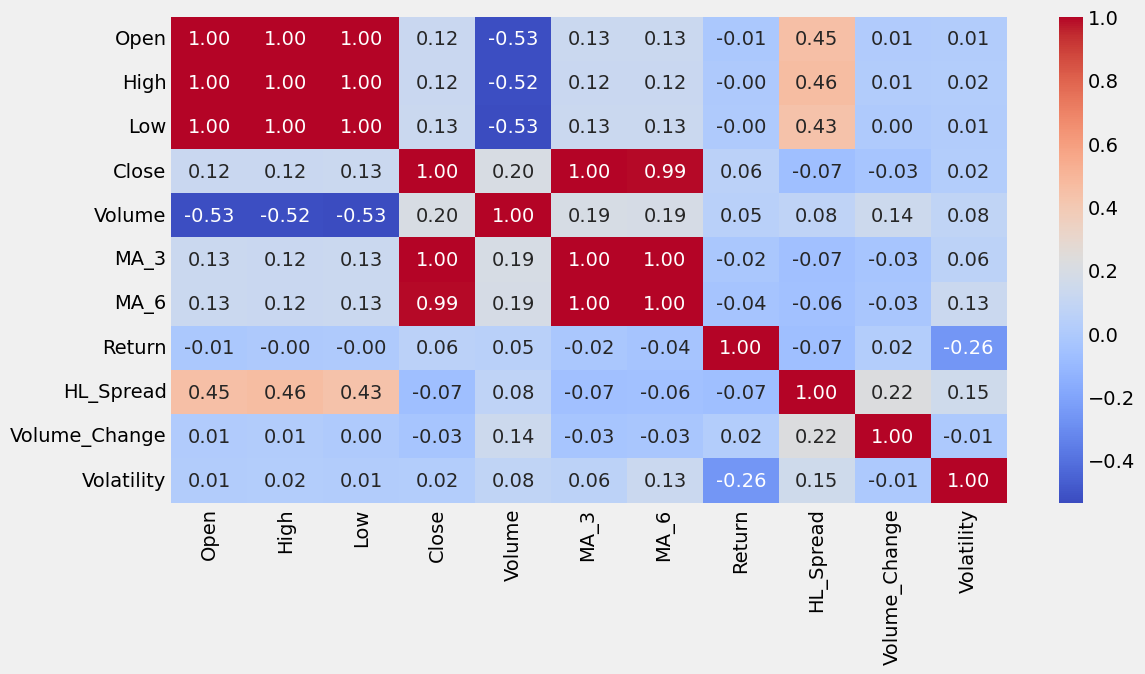

In [22]:
# to check which features should i use for the model based on correlation with close
corr = df_train.corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True ,cmap="coolwarm", fmt=".2f")
plt.show()

End of Data Wrangling

In [23]:
df_test.isnull().sum()

Open             0
High             0
Low              0
Close            0
Volume           0
MA_3             0
MA_6             0
Return           0
HL_Spread        0
Volume_Change    0
Volatility       0
dtype: int64

### LSTM Model Building

In [24]:
# Feature Scaling

features = ['Volume','MA_6','Return',]
# did not take open, high, low, MA_3, Volatility, 'HL_Spread','Volume_Change'
# because they have high correlation with 'Close' 

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(df_train[features])
X_test_scaled  = feature_scaler.transform(df_test[features])

y_train_scaled = target_scaler.fit_transform(df_train[['Close']])
y_test_scaled  = target_scaler.transform(df_test[['Close']])


In [25]:
# Sequence Creation 
look_back = 2

X_train, y_train = [], []

for i in range(look_back, len(X_train_scaled)):
    X_train.append(X_train_scaled[i-look_back:i])
    y_train.append(y_train_scaled[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test, y_test = [], []

for i in range(look_back, len(X_test_scaled)):
    X_test.append(X_test_scaled[i-look_back:i])
    y_test.append(y_test_scaled[i])

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1251, 2, 3)
Test shape: (13, 2, 3)


In [32]:
# LSTM Model
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer= Adam(learning_rate=0.001), loss='mse')

model.summary()


c:\Users\Bharat\anaconda3\envs\dataml\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 2, 50)          │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,051 (121.29 KB)

 Trainable params: 31,051 (121.29 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Train Model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1
)


Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0455 - val_loss: 5.4978e-04
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0072 - val_loss: 0.0015
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0051 - val_loss: 9.0297e-04
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046 - val_loss: 9.8097e-04
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0046 - val_loss: 0.0015
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0042 - val_loss: 3.6761e-04
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0042 - val_loss: 5.5825e-04
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0040 - val_loss: 8.2983e-04
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 - val_loss: 2.9111e-04
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0043 - val_loss: 3.0319e-04
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0036 - val_loss: 4.5282e-04
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━

In [34]:
# Predictions 
predictions = model.predict(X_test)

predicted_prices = target_scaler.inverse_transform(predictions)
actual_prices = target_scaler.inverse_transform(y_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step


In [ ]:
# ----- RMSE, MAE and R2 Evaluation -----

rmse = round(np.sqrt(mean_squared_error(actual_prices, predicted_prices)),2)
mae = round(mean_absolute_error(actual_prices, predicted_prices),2)
r2 = round(r2_score(actual_prices, predicted_prices),2)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
#RMSE: 10.3
#MAE: 8.38
#R2 Score: 0.27 # low because of size of dataset(1257 train, 20 test) very small


RMSE: 10.3
MAE: 8.38
R2 Score: 0.27


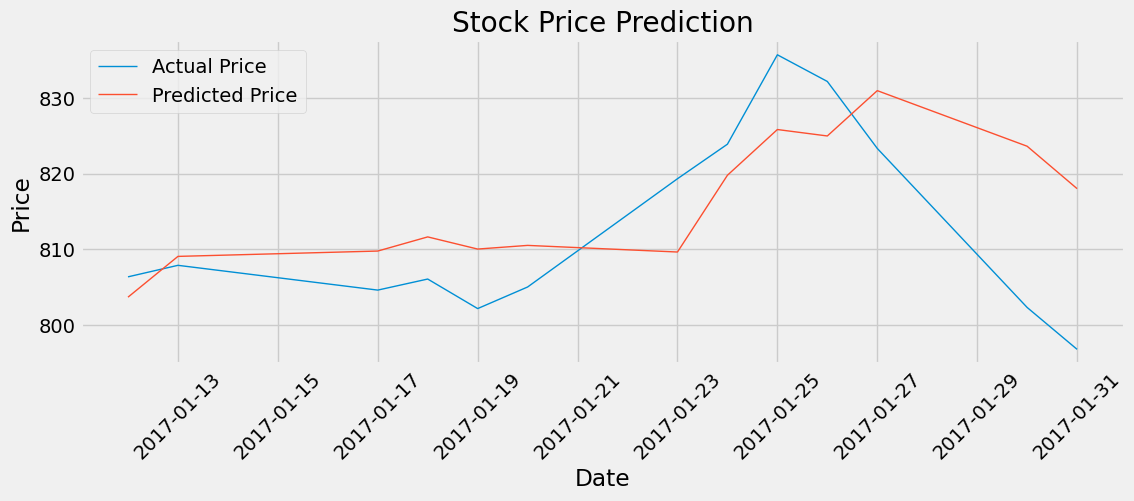

In [36]:
# Plot Results
dates = df_test.index[look_back:]

plt.figure(figsize=(12,4))
plt.plot(dates, actual_prices, label="Actual Price", linewidth=1)
plt.plot(dates, predicted_prices, label="Predicted Price", linewidth=1)
plt.title("Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.legend()
plt.show()